# ODMR Magnetic-Sensitivity Calculation

**Data:** `odmr_sweep_20260626_171343.csv` &nbsp;·&nbsp; built 2026-06-26

This notebook computes the DC magnetic sensitivity $\eta_B$ (T/$\sqrt{\mathrm{Hz}}$) from a
CW-ODMR frequency sweep, and is built to be **accurate on high-SNR spectra that show
structure** (Zeeman doublets, $^{14}$N hyperfine) which the existing
`odmr_sensitivity.quick_sensitivity` mis-handles.

## Why the old `quick_sensitivity` under-reports this dataset

`notebook_modules/odmr_sensitivity.py` fits **one single Lorentzian** to the whole
resonance. This spectrum's main feature is a **Zeeman-split doublet at ~2866 & ~2874 MHz**,
so the single fit returns a broad ~21 MHz envelope and a slope roughly **half** the true
value. Two consequences, both of which push the reported sensitivity *worse* (higher) than
reality:

1. **Slope too shallow** — magnetometry rides the *steepest* flank. The doublet's
   individual lines are ~6–14 MHz wide and far steeper than the merged envelope.
2. **Noise window on a shoulder** — the default `(2.70, 2.80) GHz` window sits on the
   residual shoulder of the resonance and is also contaminated by weak off-axis NV lines
   near 2815 / 2945 MHz, inflating the noise.

Net effect: a better-SNR spectrum gets scored ~30 nT/$\sqrt{\mathrm{Hz}}$ — no better than
the noisier "odmr 3" reference — when it should be **well below** that.

## What this notebook does instead

| Step | Method |
|---|---|
| Slope | **Multi-Lorentzian (doublet) fit** + model-free Savitzky–Golay derivative, max over the central resonance only |
| Noise | **Successive-difference** white readout noise *and* detrended clean-baseline std, with all resonance features auto-excluded |
| Sensitivity | $\eta_B = \dfrac{\sigma\,\sqrt{t_\mathrm{point}}}{\gamma\,\lvert dS/df\rvert_\max}$ for every trace, side-by-side with the old single-Lorentzian result |

The formula itself is unchanged from the old module — only the **slope** and **noise**
estimates are made structure-aware.


In [45]:
# --- Project-root + notebook_modules on sys.path (so we can import the OLD method to compare) ---
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
for _d in (PROJECT_ROOT, PROJECT_ROOT / "notebook_modules"):
    if _d.exists() and str(_d) not in _sys.path:
        _sys.path.insert(0, str(_d))
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project


## 1 · Configuration

Edit these and re-run. Everything downstream keys off this cell.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter, find_peaks

# ============================ EDIT HERE ============================
# CSV to analyse. Default = the sweep this notebook was built for.
CSV_PATH = PROJECT_ROOT / "Modules" / "odmr_sweep_20260626_171343.csv" # odmr_sweep_20260626_171343.csv
# Fallback search if it was moved into data/odmr_sweeps/:
if not CSV_PATH.exists():
    _hits = list(PROJECT_ROOT.rglob("odmr_sweep_20260626_171343.csv"))
    if _hits:
        CSV_PATH = _hits[0]

# Per-point integration time (s) used for the sqrt(t) normalisation.
# 213e-6 = the ADC readout integration (ODMR_READOUT_INTEGRATION_TUS) used to take this
# sweep, and matches the old module's DEFAULT_POINT_TIME_S so the comparison is apples-to-
# apples. If you want the *true device dwell* (reps x integration x on+off segments),
# scale eta by sqrt(t_true / 213e-6).  See the closing notes.
POINT_TIME_S = 213e-6

# NV gyromagnetic ratio (Hz per Tesla). 28.0 GHz/T matches the old module; the accepted
# value is 28.024 GHz/T (g=2.0028). Only one |0>->|+-1> branch shifts, so df/dB = gamma.
GAMMA_HZ_PER_T = 28.0e9

# Central resonance window (MHz): where the usable steepest slope lives. The slope search
# is restricted here so off-axis side lines don't pollute it. Set None to auto-pick around
# the deepest dip.
RESONANCE_WINDOW_MHZ = (2845.0, 2895.0)

# Guard radius (MHz) excluded around every detected feature when estimating noise.
NOISE_GUARD_MHZ = 18.0
# ==================================================================

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("CSV:", CSV_PATH, "| exists:", CSV_PATH.exists())

CSV: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project/Modules/odmr_sweep_20260626_171343.csv | exists: True


## 2 · Load the sweep

The loader maps the saved columns onto the same trace names the rig uses
(`signal`=MW-on PL, `reference`=MW-off PL, `contrast`=on−off) and exposes a tiny
`ODMRData` object so the **old** `quick_sensitivity` can run on it unchanged.

In [47]:
class ODMRData:
    '''Minimal container matching the rig's `d` (`.frequencies` in MHz, `.signal`,
    `.reference`, `.contrast`).'''
    def __init__(self, frequencies, signal, reference, contrast):
        self.frequencies = np.asarray(frequencies, float)
        self.signal = np.asarray(signal, float)
        self.reference = np.asarray(reference, float)
        self.contrast = np.asarray(contrast, float)

def load_odmr_csv(path):
    df = pd.read_csv(path)
    f = df["frequency_MHz"].to_numpy(float)
    sig = df["photoluminescence_mw_on_ADC"].to_numpy(float)
    ref = df["photoluminescence_mw_off_ADC"].to_numpy(float)
    con = (df["contrast_ADC"].to_numpy(float) if "contrast_ADC" in df.columns
           else sig - ref)
    order = np.argsort(f)
    return ODMRData(f[order], sig[order], ref[order], con[order]), df

d, raw_df = load_odmr_csv(CSV_PATH)
TRACES = {"signal (MW on)": d.signal, "reference (MW off)": d.reference, "contrast (on-off)": d.contrast}
step = float(np.median(np.diff(d.frequencies)))
print(f"{len(d.frequencies)} points | {d.frequencies.min():.0f}-{d.frequencies.max():.0f} MHz | step {step:.2f} MHz")
raw_df.head()

351 points | 2700-3050 MHz | step 1.00 MHz


,frequency_MHz,photoluminescence_mw_on_ADC,photoluminescence_mw_off_ADC,contrast_ADC,contrast_percent
0,2700.000000,-57.929593,-51.857974,-6.071619,11.746564
1,2701.000000,-59.068964,-51.170514,-7.898450,15.673732
2,2701.999999,-58.335222,-51.329575,-7.005647,14.025417
3,2702.999999,-57.907458,-51.312526,-6.594932,12.920059
4,2703.999998,-58.659440,-51.569533,-7.089907,13.835007


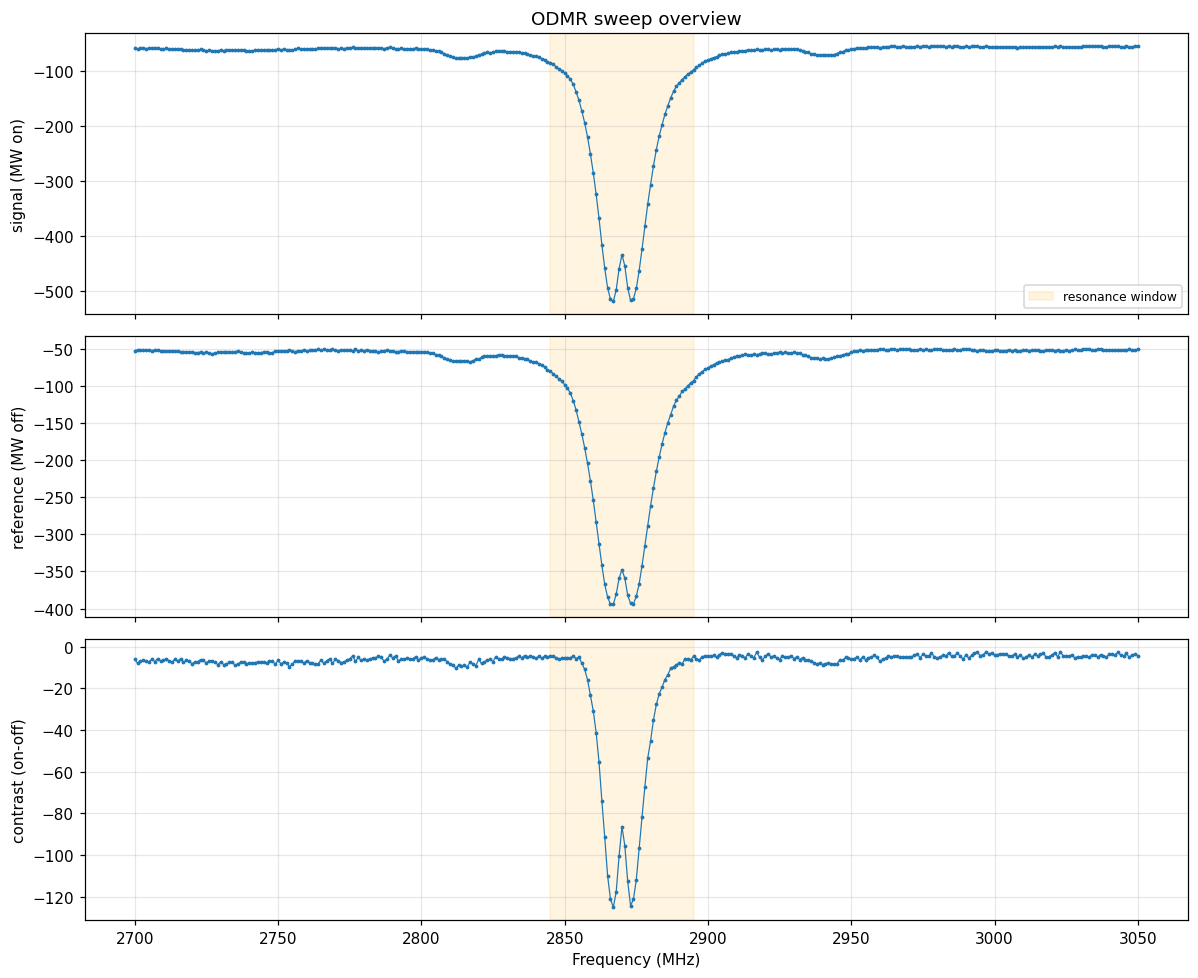

In [48]:
fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for a, (name, y) in zip(ax, TRACES.items()):
    a.plot(d.frequencies, y, ".-", ms=3, lw=0.8)
    a.set_ylabel(name)
if RESONANCE_WINDOW_MHZ:
    for a in ax:
        a.axvspan(*RESONANCE_WINDOW_MHZ, color="orange", alpha=0.12, label="resonance window")
    ax[0].legend(loc="lower right", fontsize=8)
ax[-1].set_xlabel("Frequency (MHz)")
ax[0].set_title("ODMR sweep overview")
plt.tight_layout(); plt.show()

## 3 · Baseline: the old single-Lorentzian `quick_sensitivity`

Run the existing module verbatim so we have a like-for-like reference. Note the broad
fitted FWHM and the resulting slope — both symptoms of fitting the doublet as one line.

OLD [reference] FWHM= 20.65 MHz | max|slope|= 23.34 ADC/MHz | noise_std=1.370 | -> 30.60 nT/sqrt(Hz)
OLD [signal   ] FWHM= 20.65 MHz | max|slope|= 23.34 ADC/MHz | noise_std=1.370 | -> 30.60 nT/sqrt(Hz)


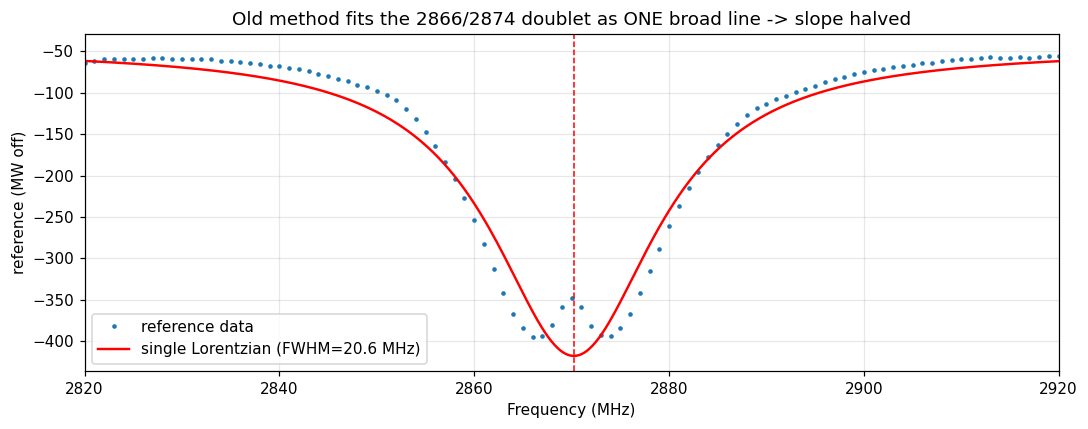

In [49]:
from odmr_sensitivity import estimate_odmr_sensitivity, lorentzian

old_results = {}
for tr in ("reference", "signal"):
    r = estimate_odmr_sensitivity(d, trace=tr, point_time_s=POINT_TIME_S,
                                  noise_window_ghz=(2.70, 2.80))
    r = r if "sensitivity_text" in r else r[tr]
    old_results[tr] = r
    print(f"OLD [{tr:9s}] FWHM={r['fwhm_mhz']:6.2f} MHz | "
          f"max|slope|={r['max_slope_per_ghz']/1e3:6.2f} ADC/MHz | "
          f"noise_std={r['noise_std']:.3f} | -> {r['sensitivity_text']}")

# Reproduce the old single-Lorentzian fit (in MHz) purely for visualisation
xg = d.frequencies / 1e3  # GHz, as the module works internally
p0 = [old_results["reference"]["center_ghz"], old_results["reference"]["gamma_ghz"],
      d.reference.min() - np.median(d.reference), float(np.median(d.reference))]
popt_old, _ = curve_fit(lorentzian, xg, d.reference, p0=p0, maxfev=200000)
xf = np.linspace(d.frequencies.min(), d.frequencies.max(), 2000)
yfit_old = lorentzian(xf/1e3, *popt_old)

plt.figure(figsize=(10, 4))
plt.plot(d.frequencies, d.reference, ".", ms=4, label="reference data")
plt.plot(xf, yfit_old, "r-", lw=1.6, label=f"single Lorentzian (FWHM={old_results['reference']['fwhm_mhz']:.1f} MHz)")
plt.axvline(old_results["reference"]["center_mhz"], color="red", ls="--", lw=1)
plt.xlim(2820, 2920); plt.xlabel("Frequency (MHz)"); plt.ylabel("reference (MW off)")
plt.title("Old method fits the 2866/2874 doublet as ONE broad line -> slope halved")
plt.legend(); plt.tight_layout(); plt.show()

## 4 · Detect features & estimate readout noise

We detect every resonance dip, then estimate noise on the genuinely off-resonance points
two ways:

- **`sdiff`** — successive-difference white readout noise, $\sigma=\mathrm{std}(\Delta y)/\sqrt2$.
  Immune to slow drift and broad side-lines; this is the shot-noise-like floor.
- **`baseline`** — std of the off-resonance points after a cubic detrend, with **iterative
  sigma-clipping** so broad off-axis lines the central mask misses don't inflate it
  (more conservative; retains low-frequency wander).

In [50]:
def detect_features(freq, trace, prom_frac=0.06, min_sep_mhz=3.0):
    '''Return MHz locations of dips in `trace`.'''
    y = savgol_filter(trace, 9, 3)
    dip = -(y - np.median(y))
    span = dip.max() - dip.min()
    pk, _ = find_peaks(dip, prominence=max(span*prom_frac, 1e-9),
                       distance=max(int(min_sep_mhz/step), 1))
    return freq[pk]

def offres_mask(freq, features, guard=NOISE_GUARD_MHZ):
    m = np.ones_like(freq, bool)
    for c in features:
        m &= np.abs(freq - c) > guard
    return m

def noise_estimates(freq, y, init_mask, k=4.0, n_iter=6):
    '''White (successive-difference) noise + sigma-clipped detrended baseline.

    The sigma-clip removes BROAD off-axis lines (e.g. ~2815 / ~2945 MHz) that the
    central-feature mask misses and which otherwise wreck the PL-channel baseline.'''
    sdiff = (float(np.std(np.diff(y[init_mask]), ddof=1) / np.sqrt(2))
             if init_mask.sum() > 3 else np.nan)
    m = init_mask.copy()
    for _ in range(n_iter):
        coef = np.polyfit(freq[m], y[m], 3)
        resid = y - np.polyval(coef, freq)
        m_new = init_mask & (np.abs(resid) < k * max(sdiff, 1e-9))
        if m_new.sum() < 15 or np.array_equal(m_new, m):
            m = m_new if m_new.sum() >= 15 else m
            break
        m = m_new
    coef = np.polyfit(freq[m], y[m], 3)
    baseline = float(np.std((y - np.polyval(coef, freq))[m], ddof=1))
    return {"sdiff": sdiff, "baseline": baseline, "kept_mask": m}

# Detect across all traces, union the feature list (PL channels also show off-axis lines)
features = np.unique(np.concatenate([
    detect_features(d.frequencies, d.contrast),
    detect_features(d.frequencies, d.reference),
    detect_features(d.frequencies, d.signal),
]))
features = np.round(np.sort(features), 1)
mask = offres_mask(d.frequencies, features)
print("Detected feature freqs (MHz):", features)
print(f"Off-resonance points used for noise: {mask.sum()} / {len(d.frequencies)}\n")

noise = {}
for name, y in TRACES.items():
    noise[name] = noise_estimates(d.frequencies, y, mask)
    print(f"{name:18s}  sdiff(white)={noise[name]['sdiff']:.3f}   "
          f"baseline(clipped)={noise[name]['baseline']:.3f} ADC   "
          f"[{noise[name]['kept_mask'].sum()} clean pts]")

Detected feature freqs (MHz): [2866. 2874.]
Off-resonance points used for noise: 307 / 351

signal (MW on)      sdiff(white)=0.947   baseline(clipped)=1.343 ADC   [201 clean pts]
reference (MW off)  sdiff(white)=0.885   baseline(clipped)=1.484 ADC   [202 clean pts]
contrast (on-off)   sdiff(white)=0.767   baseline(clipped)=1.046 ADC   [298 clean pts]


## 5 · True maximum slope

Two structure-aware estimates of $\lvert dS/df\rvert_\max$ over the central resonance:

- **Multi-Lorentzian fit** (one Lorentzian per detected line in the window) → analytic
  derivative. This is the headline slope: clean and not biased up by noise.
- **Model-free** Savitzky–Golay derivative of the raw trace → cross-check.

In [51]:
def multi_lorentzian(x, off, *p):
    y = np.full_like(x, off, dtype=float)
    for i in range(len(p)//3):
        c, g, A = p[3*i:3*i+3]
        y = y + A*g**2/((x-c)**2 + g**2)
    return y

def multi_lorentzian_deriv(x, p):  # p = flat [c,g,A]*n  (offset has zero derivative)
    d_ = np.zeros_like(x, dtype=float)
    for i in range(len(p)//3):
        c, g, A = p[3*i:3*i+3]
        d_ = d_ + A*g**2*(-2*(x-c))/((x-c)**2 + g**2)**2
    return d_

def resonance_window(freq, trace):
    if RESONANCE_WINDOW_MHZ:
        return RESONANCE_WINDOW_MHZ
    c = freq[np.argmax(np.abs(trace - np.median(trace)))]
    return (c - 30, c + 30)

def fit_slope(freq, y):
    lo, hi = resonance_window(freq, y)
    m = (freq >= lo) & (freq <= hi)
    xc, yc = freq[m], y[m]
    cen = detect_features(xc, yc, prom_frac=0.05) if len(xc) else np.array([])
    if len(cen) == 0:
        cen = np.array([xc[np.argmin(yc)]])
    off0 = float(np.median(np.concatenate([yc[:3], yc[-3:]])))  # window edges = local baseline
    p0 = [off0]; lb = [-np.inf]; ub = [np.inf]
    for c in cen:
        depth = yc.min() - off0
        p0 += [c, 3.0, depth]; lb += [c-6, 0.3, -np.inf]; ub += [c+6, 18.0, np.inf]
    try:
        popt, _ = curve_fit(multi_lorentzian, xc, yc, p0=p0, bounds=(lb, ub), maxfev=300000)
    except Exception:
        popt, _ = curve_fit(multi_lorentzian, xc, yc, p0=p0, maxfev=300000)
    xfine = np.linspace(xc.min(), xc.max(), 6000)
    der = multi_lorentzian_deriv(xfine, popt[1:])          # ADC / MHz
    k = int(np.argmax(np.abs(der)))
    return {"slope": float(np.abs(der[k])), "f_at_slope": float(xfine[k]),
            "popt": popt, "n_lines": len(cen), "window": (lo, hi),
            "xfine": xfine, "model": multi_lorentzian(xfine, *popt)}

def numeric_slope(freq, y):
    lo, hi = resonance_window(freq, y)
    der = savgol_filter(y, 11, 3, deriv=1, delta=step)      # ADC / MHz
    m = (freq >= lo) & (freq <= hi)
    return float(np.max(np.abs(der[m])))

slope = {}
for name, y in TRACES.items():
    fr = fit_slope(d.frequencies, y)
    slope[name] = {"fit": fr["slope"], "fit_f": fr["f_at_slope"],
                   "numeric": numeric_slope(d.frequencies, y), "_fr": fr}
    print(f"{name:18s}  fit max|slope|={fr['slope']:6.2f} ADC/MHz @ {fr['f_at_slope']:7.1f} MHz "
          f"({fr['n_lines']} lines)   numeric={slope[name]['numeric']:6.2f} ADC/MHz")

signal (MW on)      fit max|slope|= 53.41 ADC/MHz @  2862.5 MHz (2 lines)   numeric= 45.40 ADC/MHz
reference (MW off)  fit max|slope|= 34.17 ADC/MHz @  2861.5 MHz (2 lines)   numeric= 29.51 ADC/MHz
contrast (on-off)   fit max|slope|= 23.46 ADC/MHz @  2864.2 MHz (2 lines)   numeric= 18.02 ADC/MHz


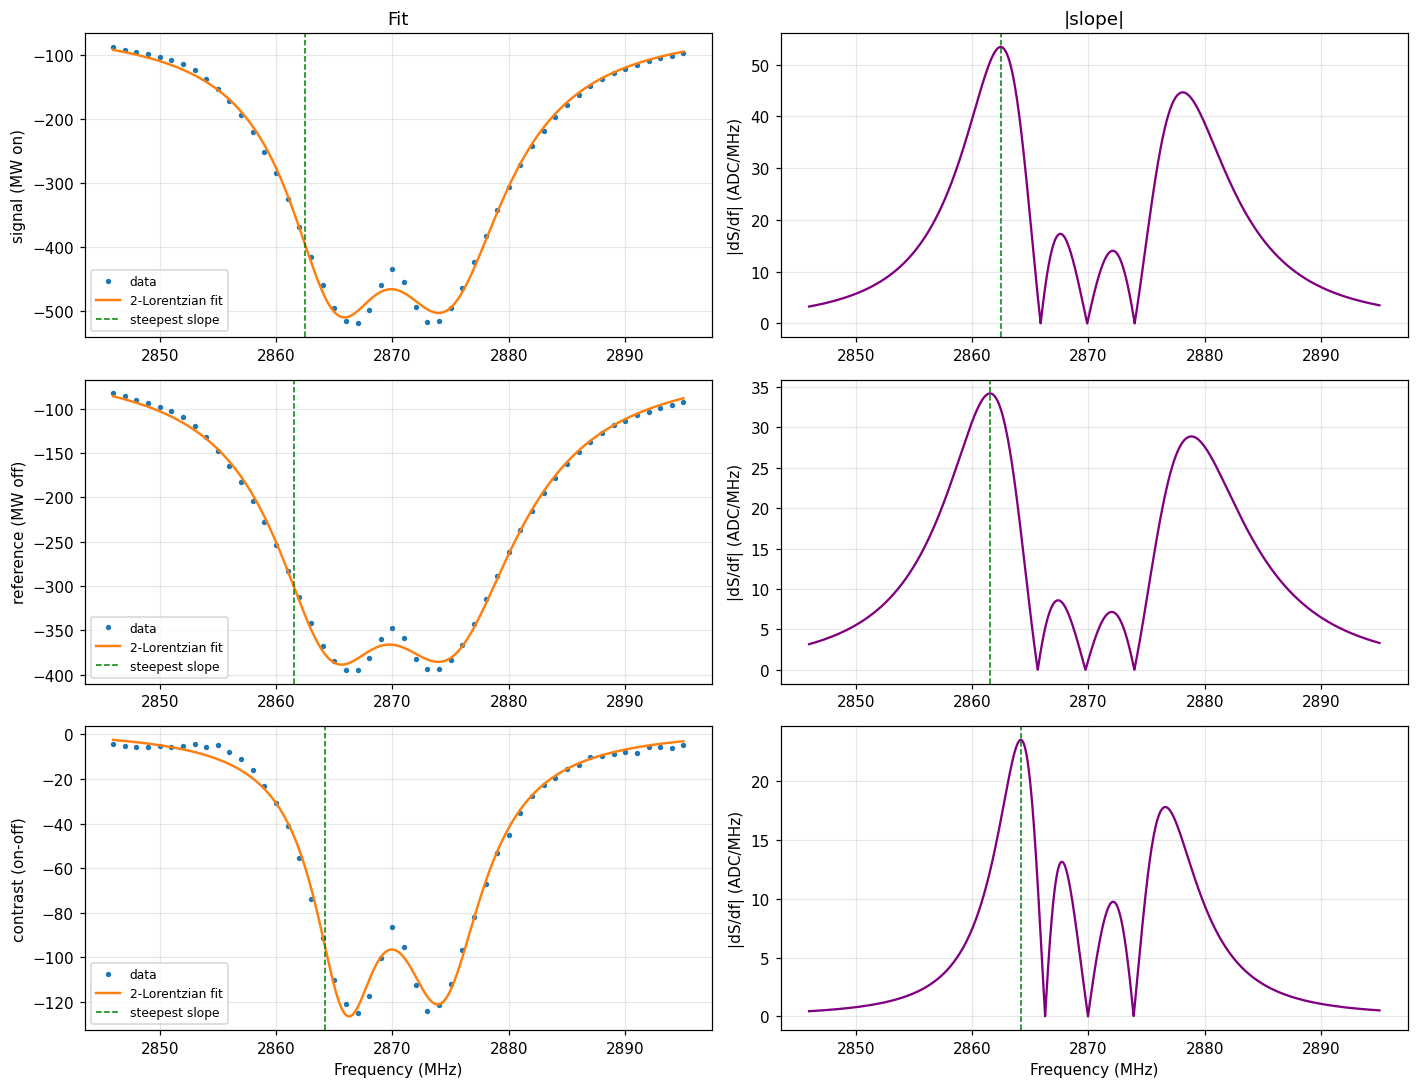

In [52]:
# Show the doublet fit + derivative for each trace
fig, ax = plt.subplots(3, 2, figsize=(13, 10))
for row, (name, y) in enumerate(TRACES.items()):
    fr = slope[name]["_fr"]; lo, hi = fr["window"]
    m = (d.frequencies >= lo) & (d.frequencies <= hi)
    ax[row, 0].plot(d.frequencies[m], y[m], ".", ms=5, label="data")
    ax[row, 0].plot(fr["xfine"], fr["model"], "-", lw=1.6, label=f"{fr['n_lines']}-Lorentzian fit")
    ax[row, 0].axvline(fr["f_at_slope"], color="green", ls="--", lw=1, label="steepest slope")
    ax[row, 0].set_ylabel(name); ax[row, 0].legend(fontsize=8)
    der = multi_lorentzian_deriv(fr["xfine"], fr["popt"][1:])
    ax[row, 1].plot(fr["xfine"], np.abs(der), color="purple")
    ax[row, 1].axvline(fr["f_at_slope"], color="green", ls="--", lw=1)
    ax[row, 1].set_ylabel("|dS/df| (ADC/MHz)")
ax[0, 0].set_title("Fit"); ax[0, 1].set_title("|slope|")
ax[-1, 0].set_xlabel("Frequency (MHz)"); ax[-1, 1].set_xlabel("Frequency (MHz)")
plt.tight_layout(); plt.show()

## 6 · Sensitivity

$$\eta_B = \frac{\sigma_S\,\sqrt{t_\mathrm{point}}}{\gamma\,\lvert dS/df\rvert_\max}$$

with $\gamma$ converting frequency slope (ADC/Hz) to field slope (ADC/T). Computed for every
trace using the fitted slope, and reported as a **range** between the optimistic white-noise
floor (`sdiff`) and the conservative detrended baseline.

In [53]:
def sensitivity(noise_adc, slope_adc_per_mhz, point_time_s=POINT_TIME_S):
    slope_adc_per_hz = slope_adc_per_mhz / 1e6
    return noise_adc * np.sqrt(point_time_s) / (GAMMA_HZ_PER_T * slope_adc_per_hz)  # T/sqrt(Hz)

rows = []
for name, y in TRACES.items():
    s = slope[name]["fit"]
    eta_white = sensitivity(noise[name]["sdiff"], s) * 1e9
    eta_base  = sensitivity(noise[name]["baseline"], s) * 1e9
    rows.append({
        "trace": name,
        "slope_ADC/MHz": round(s, 2),
        "noise_white": round(noise[name]["sdiff"], 3),
        "noise_baseline": round(noise[name]["baseline"], 3),
        "eta_white_nT": round(eta_white, 1),
        "eta_baseline_nT": round(eta_base, 1),
    })
summary = pd.DataFrame(rows).set_index("trace")

old_ref_nT = old_results["reference"]["sensitivity_t_rt_hz"] * 1e9
print(f"OLD single-Lorentzian (reference):  {old_ref_nT:.1f} nT/sqrt(Hz)\n")
summary

OLD single-Lorentzian (reference):  30.6 nT/sqrt(Hz)



,slope_ADC/MHz,noise_white,noise_baseline,eta_white_nT,eta_baseline_nT
trace,,,,,
signal (MW on),53.41,0.947,1.343,9.2,13.1
reference (MW off),34.17,0.885,1.484,13.5,22.6
contrast (on-off),23.46,0.767,1.046,17.0,23.3


NEW best trace: signal (MW on)
   eta_B = 9.2 - 13.1 nT/sqrt(Hz)   (white floor -> detrended baseline)
OLD method reported: 30.6 nT/sqrt(Hz)
   improvement: 2.3x (conservative) to 3.3x (white-noise floor)


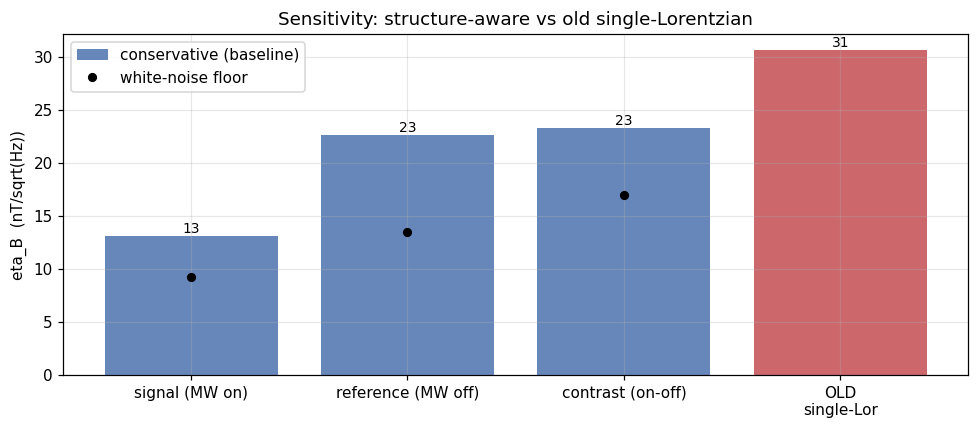

In [54]:
# Headline + comparison bar chart
best_trace = summary["eta_baseline_nT"].idxmin()
lo_nT = summary.loc[best_trace, "eta_white_nT"]; hi_nT = summary.loc[best_trace, "eta_baseline_nT"]
print(f"NEW best trace: {best_trace}")
print(f"   eta_B = {lo_nT:.1f} - {hi_nT:.1f} nT/sqrt(Hz)   (white floor -> detrended baseline)")
print(f"OLD method reported: {old_ref_nT:.1f} nT/sqrt(Hz)")
print(f"   improvement: {old_ref_nT/hi_nT:.1f}x (conservative) to {old_ref_nT/lo_nT:.1f}x (white-noise floor)")

fig, ax = plt.subplots(figsize=(9, 4))
labels = list(summary.index) + ["OLD\nsingle-Lor"]
base = list(summary["eta_baseline_nT"]) + [old_ref_nT]
white = list(summary["eta_white_nT"]) + [old_ref_nT]
xpos = np.arange(len(labels))
ax.bar(xpos, base, color=["#4c72b0"]*len(summary) + ["#c44e52"], alpha=0.85, label="conservative (baseline)")
ax.errorbar(xpos[:len(summary)], white[:len(summary)], fmt="o", color="k", ms=5, label="white-noise floor")
for i, v in enumerate(base):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylabel("eta_B  (nT/sqrt(Hz))"); ax.set_title("Sensitivity: structure-aware vs old single-Lorentzian")
ax.legend(); plt.tight_layout(); plt.show()

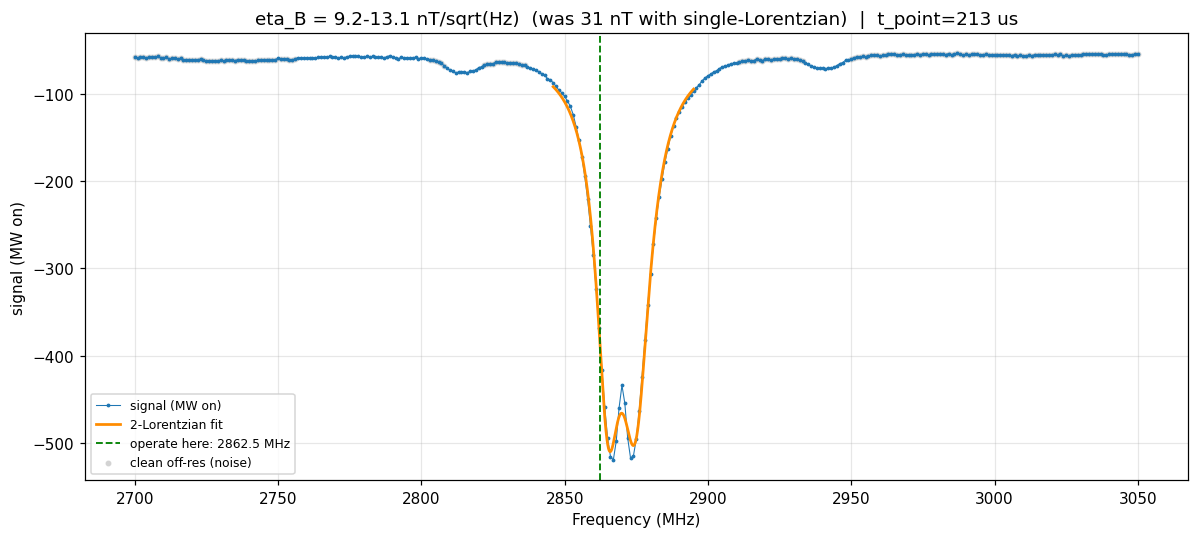

In [55]:
# Final annotated figure on the best trace
y = TRACES[best_trace]; fr = slope[best_trace]["_fr"]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(d.frequencies, y, ".-", ms=3, lw=0.7, label=best_trace)
ax.plot(fr["xfine"], fr["model"], "-", color="darkorange", lw=1.8, label=f"{fr['n_lines']}-Lorentzian fit")
ax.axvline(fr["f_at_slope"], color="green", ls="--", lw=1.2,
           label=f"operate here: {fr['f_at_slope']:.1f} MHz")
_km = noise[best_trace]["kept_mask"]
ax.scatter(d.frequencies[_km], y[_km], s=8, color="lightgray", zorder=0, label="clean off-res (noise)")
ax.set_xlabel("Frequency (MHz)"); ax.set_ylabel(best_trace)
ax.set_title(f"eta_B = {lo_nT:.1f}-{hi_nT:.1f} nT/sqrt(Hz)  (was {old_ref_nT:.0f} nT with single-Lorentzian)  |  t_point={POINT_TIME_S*1e6:.0f} us")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7 · Notes & how to adapt

- **Which trace to quote.** `contrast` is the most robust device number: common-mode
  laser/PL fluctuations cancel, so its noise floor is flat and window-independent. The PL
  channels (`signal`/`reference`) have steeper slopes and reach a lower $\eta_B$, but only
  if you genuinely read a single channel at the operating point. Quote the trace your
  lock-in actually parks on.
- **`POINT_TIME_S`.** Set to the ADC integration (213 µs) for parity with the old module.
  For the *true device* sensitivity use the real per-point dwell
  (reps × integration × on+off segments) and remember $\eta_B \propto \sqrt{t_\mathrm{point}}$:
  a 10× longer dwell multiplies $\eta_B$ by $\sqrt{10}\approx3.2$.
- **White vs baseline noise.** `sdiff` is the shot/white-noise floor (optimistic);
  `baseline` keeps slow drift (conservative). Real performance sits between them — report
  the range, as above.
- **Other spectra.** Point `CSV_PATH` at any sweep with the same columns. Features and line
  count are auto-detected; set `RESONANCE_WINDOW_MHZ = None` to auto-center on the deepest
  dip, and widen `NOISE_GUARD_MHZ` if weak off-axis lines leak into the noise window.
- **$\gamma$.** 28.0 GHz/T matches the old module; switch `GAMMA_HZ_PER_T` to 28.024e9 for
  the textbook value (≈0.1 % change).
